In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn : Modèle et Tuning
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

# Métriques
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, auc, 
                             classification_report, confusion_matrix, accuracy_score, brier_score_loss)

# Interprétabilité
from sklearn.inspection import PartialDependenceDisplay

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Stockage pour comparaison
mes_predictions_proba = {}

In [2]:
PATH = '/kaggle/input/notebooks/yasminabouziane/data-rainprediction/' 
print("Chargement des données...")

X_train = pd.read_csv(os.path.join(PATH, 'X_train.csv'))
y_train = pd.read_csv(os.path.join(PATH, 'y_train.csv'))['RainTomorrow']
X_test = pd.read_csv(os.path.join(PATH, 'X_test.csv'))
y_test = pd.read_csv(os.path.join(PATH, 'y_test.csv'))['RainTomorrow']

print(f"Données chargées : Train={X_train.shape}, Test={X_test.shape}")

Chargement des données...
Données chargées : Train=(113754, 115), Test=(28439, 115)


In [3]:
print("Optimisation de l'Arbre de Décision...")

# 1. Définition de la grille
param_dist = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 10, 50, 100],
    'min_samples_leaf': [1, 5, 20],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None] # Crucial pour le déséquilibre
}

# 2. Stratégie de validation croisée stable
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Recherche aléatoire
tree_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=15, 
    cv=cv_strategy, 
    scoring='roc_auc', 
    n_jobs=-1,
    random_state=42
)

tree_search.fit(X_train, y_train)
best_tree = tree_search.best_estimator_

print(f"Meilleurs paramètres : {tree_search.best_params_}")
print(f"Meilleur score ROC-AUC (Train CV) : {tree_search.best_score_:.4f}")

Optimisation de l'Arbre de Décision...
Meilleurs paramètres : {'min_samples_split': 100, 'min_samples_leaf': 20, 'max_depth': 10, 'criterion': 'gini', 'class_weight': None}
Meilleur score ROC-AUC (Train CV) : 0.8508


In [4]:
print("\nCalibration du modèle et Comparaison des performances...")

from sklearn.metrics import brier_score_loss, log_loss

# Modèle brut
y_proba_raw = best_tree.predict_proba(X_test)[:, 1]

# Application de la calibration (Isotonic)
calibrator = CalibratedClassifierCV(best_tree, method='isotonic', cv=5)
calibrator.fit(X_train, y_train)
y_proba_calib = calibrator.predict_proba(X_test)[:, 1]

mes_predictions_proba["Arbre_Brut"] = y_proba_raw
mes_predictions_proba["Arbre_Calibre"] = y_proba_calib

# 1. Calcul des scores Bruts
brier_raw = brier_score_loss(y_test, y_proba_raw)
logloss_raw = log_loss(y_test, y_proba_raw)

# 2. Calcul des scores Calibrés
brier_calib = brier_score_loss(y_test, y_proba_calib)
logloss_calib = log_loss(y_test, y_proba_calib)

print(f"\nLog-Loss (Pénalité de fausse certitude) :")
print(f"   - Brut    : {logloss_raw:.4f}")
print(f"   - Calibré : {logloss_calib:.4f}")


Calibration du modèle et Comparaison des performances...

Log-Loss (Pénalité de fausse certitude) :
   - Brut    : 0.4023
   - Calibré : 0.3541



Évaluation rigoureuse...


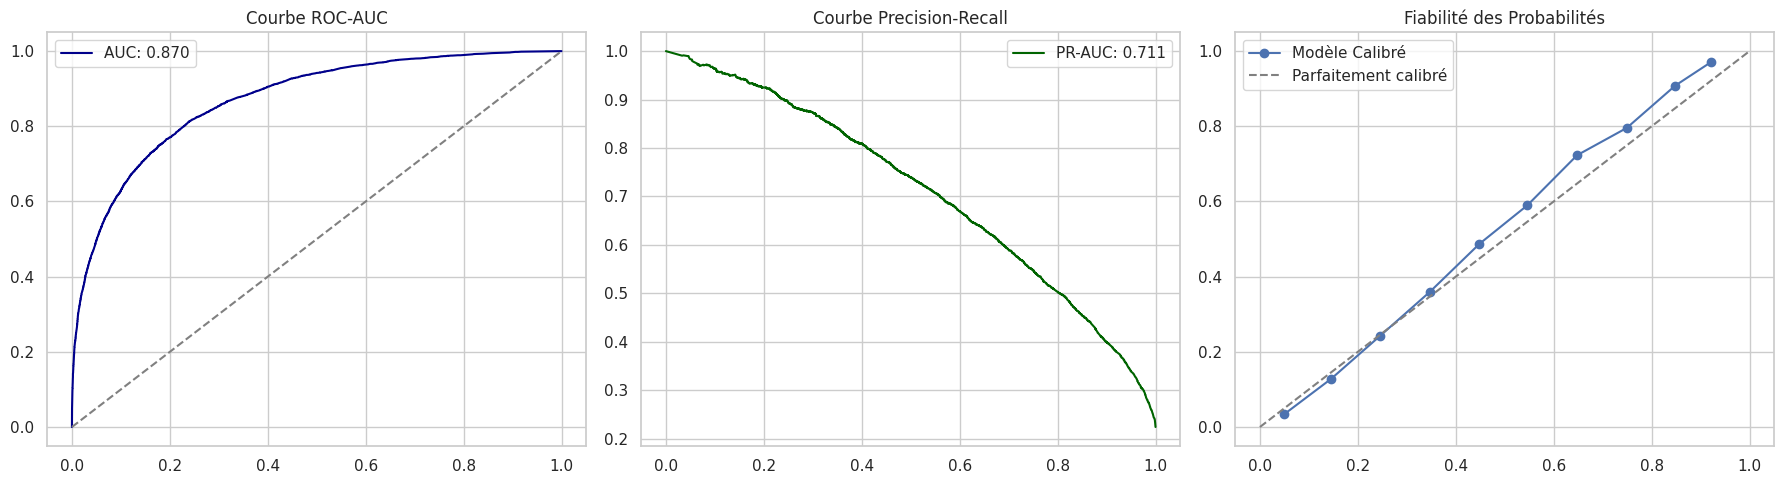

In [5]:
print("\nÉvaluation rigoureuse...")

plt.figure(figsize=(18, 5))

# A. Courbe ROC
plt.subplot(1, 3, 1)
fpr, tpr, _ = roc_curve(y_test, y_proba_calib)
plt.plot(fpr, tpr, label=f'AUC: {auc(fpr, tpr):.3f}', color='darkblue')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.title("Courbe ROC-AUC")
plt.legend()

# B. Courbe Precision-Recall (Déséquilibre des classes)
plt.subplot(1, 3, 2)
prec, rec, _ = precision_recall_curve(y_test, y_proba_calib)
plt.plot(rec, prec, label=f'PR-AUC: {auc(rec, prec):.3f}', color='darkgreen')
plt.title("Courbe Precision-Recall")
plt.legend()

# C. Diagramme de Calibration (Fiabilité)
plt.subplot(1, 3, 3)
prob_true, prob_pred = calibration_curve(y_test, y_proba_calib, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Modèle Calibré')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Parfaitement calibré')
plt.title("Fiabilité des Probabilités")
plt.legend()

plt.tight_layout()
plt.show()


 Analyse des erreurs et importance des variables...


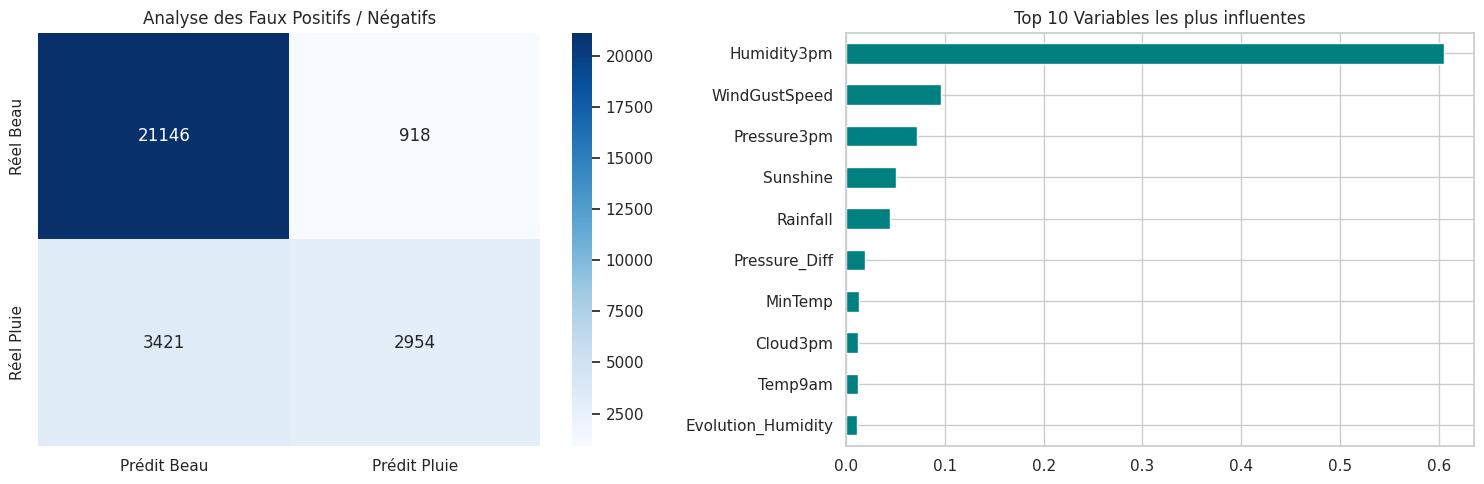


Analyse de l'impact de la variable principale (PDP)...


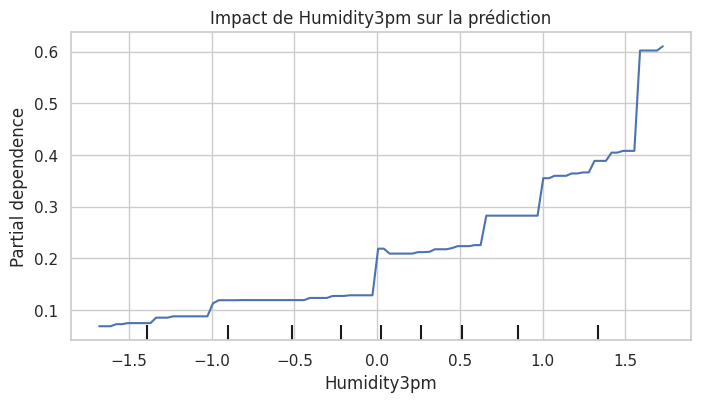


Rapport de classification détaillé :
              precision    recall  f1-score   support

  Beau temps       0.86      0.96      0.91     22064
       Pluie       0.76      0.46      0.58      6375

    accuracy                           0.85     28439
   macro avg       0.81      0.71      0.74     28439
weighted avg       0.84      0.85      0.83     28439



In [6]:
print("\n Analyse des erreurs et importance des variables...")

# 1. Matrice de Confusion
y_pred = (y_proba_calib > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit Beau', 'Prédit Pluie'], 
            yticklabels=['Réel Beau', 'Réel Pluie'])
plt.title("Analyse des Faux Positifs / Négatifs")

# 2. Feature Importance (Top 10)
plt.subplot(1, 2, 2)
importances = pd.Series(best_tree.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=True).tail(10).plot(kind='barh', color='teal')
plt.title("Top 10 Variables les plus influentes")

plt.tight_layout()
plt.show()

# 3. Partial Dependence Plot (PDP)
print("\nAnalyse de l'impact de la variable principale (PDP)...")
top_var = importances.idxmax()
fig, ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(best_tree, X_train, [top_var], ax=ax)
plt.title(f"Impact de {top_var} sur la prédiction")
plt.show()

print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred, target_names=['Beau temps', 'Pluie']))